# 07 - WBF Regime Analysis

This notebook implements the Korolev and Mazin (2003) formulation to calculate the critical updraft velocities for ice growth ($u_{zi}$) and liquid droplet growth ($u_{zw}$). It then compares the actual model vertical velocity against these thresholds to determine the occurrence of the Wegener-Bergeron-Findeisen (WBF) regime in the tracked plumes, directly comparable to the findings in Omanovic et al. (2024, 2025).

In [1]:
from pathlib import Path
import sys
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

src_dir = next(p / "src" for p in (Path.cwd(), *Path.cwd().parents)
               if (p / "src" / "polarcap_runtime.py").is_file())
sys.path.insert(0, str(src_dir))

from utilities import load_plume_path_runs

In [2]:
# --- Configuration ---
PROCESSED_ROOT = Path("../data/processed")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

SEEDING_START = np.datetime64("2023-01-25T12:30:00")

# Korolev formulation (from Omanovic_etal_2024/korolev.py)
def korolev(T, p, rho_air, qv, Ni, qi, Nw, qw):
    """
    Calculate critical updraft velocities for ice and water.
    T: temperature [K], p: pressure [Pa], rho_air: [kg/m3], qv: [kg/kg],
    Ni: [m-3], qi: [kg/kg], Nw: [m-3], qw: [kg/kg].
    Returns NaN where inputs are invalid to avoid divide-by-zero.
    """
    with np.errstate(divide="ignore", invalid="ignore"):
        T0 = 273.15
        p0 = 101325
        rho_i, rho_w = 917, 997
        Rv, Mw, Ma = 461.5, 0.018, 0.028
        c, g = 1, 9.81
        valid = (
            np.isfinite(T) & (T > 100) & (T < 400) &
            np.isfinite(p) & (p > 1e3) & (p < 2e5) &
            np.isfinite(rho_air) & (rho_air > 0.1) & (rho_air < 2) &
            np.isfinite(qv) & (qv > 1e-10) & (qv < 0.1)
        )
        T = np.where(valid, T, T0)
        p = np.where(valid, p, p0)
        rho_air = np.where(valid, rho_air, 1.0)
        qv = np.where(valid, qv, 1e-5)
        Ni_safe = np.where(Ni > 0, Ni, 1e-10)
        Nw_safe = np.where(Nw > 0, Nw, 1e-10)
        mi = qi / (Ni_safe / rho_air)
        mi = np.where((mi > 0) & np.isfinite(mi), mi, 1e-20)
        voli = mi / rho_i
        ri = ((3 * voli) / (4 * np.pi)) ** (1. / 3.)
        mw = qw / Nw_safe
        mw = np.where((mw > 0) & np.isfinite(mw), mw, 1e-20)
        volw = mw / rho_w
        rw = ((3 * volw) / (4 * np.pi)) ** (1. / 3.)
        Aw, Bw = 2.53e11, 5420
        e_sw = Aw * np.exp(-(Bw / T))
        Ai, Bi = 3.64e12, 6148
        e_si = Ai * np.exp(-(Bi / T))
        e_sw = np.where(e_sw > 0, e_sw, np.nan)
        e_si = np.where(e_si > 0, e_si, np.nan)
        Rd, cp_d = 287, 1005
        denom_omega = p - e_sw
        omega = np.where(np.abs(denom_omega) > 1, (Mw / Ma) * (e_sw / denom_omega), 0)
        cp = cp_d + 1884 * omega
        Ra = (1 + 0.608 * qv) * Rd
        Ra = np.where(Ra > 0, Ra, np.nan)
        k = 4.1868e-3 * (5.69 + 0.017 * (T - T0))
        Dv = 2.11e-5 * (T / T0) ** 1.94 * (p0 / np.where(p > 0, p, np.nan))
        Lv = (56579 - 42.212 * T + np.exp(0.1149 * (281.6 - T))) * (1 / Mw)
        Ls = (46782.5 + 35.8925 * T - 0.07414 * (T ** 2) + 541.5 * np.exp(-(T / 123.75)) ** 2) * (1 / Mw)
        denom_Aice = (rho_i * Ls ** 2) / (k * Rv * (T ** 2)) + (rho_i * Rv * T) / (e_si * Dv)
        Aice = np.where(np.isfinite(denom_Aice) & (denom_Aice > 0), 1 / denom_Aice, np.nan)
        Bice = 4 * np.pi / rho_air * rho_i * ((e_sw / e_si) - 1) * c * Aice
        a2 = 1 / qv + (Lv * Ls) / (cp * Rv * (T ** 2))
        bi = a2 * Bice
        a0 = g / (Ra * T) * ((Lv * Ra) / (cp * Rv * T) - 1)
        a0 = np.where(np.isfinite(a0) & (np.abs(a0) > 1e-30), a0, np.nan)
        u_z_i = (bi * Ni * ri) / a0
        denom_Awat = (rho_w * Lv ** 2) / (k * Rv * T ** 2) + (rho_w * Rv * T) / (e_sw * Dv)
        Awat = np.where(np.isfinite(denom_Awat) & (denom_Awat > 0), 1 / denom_Awat, np.nan)
        Bwat = 4 * np.pi * rho_w * Awat / rho_air
        a1 = 1 / qv + Lv ** 2 / (cp * Rv * T ** 2)
        bw = a1 * Bwat
        es_ratio = np.where(e_si > 0, e_sw / e_si, np.nan)
        denom_uzw = es_ratio * a0
        u_z_w = np.where(np.isfinite(denom_uzw) & (np.abs(denom_uzw) > 1e-30),
                         ((1 - es_ratio) * bw * Nw * rho_air * rw) / denom_uzw, np.nan)
        u_z_i = np.where(valid, u_z_i, np.nan)
        u_z_w = np.where(valid, u_z_w, np.nan)
        ri = np.where(valid, ri, np.nan)
        rw = np.where(valid, rw, np.nan)
    return u_z_i, u_z_w, ri, rw


In [3]:
# --- Load model data ---
# Dataset units (from data): t K, pp Pa, qv gm-3, rho kg/m³, wt m/s, qc qi gm-3/gL-1, icnc L-1, cdnc cm-3
datasets = load_plume_path_runs(processed_root=PROCESSED_ROOT, kinds=("integrated", "extreme", "vertical"))
# use first available kind per run
kind = "integrated"  # or "extreme" if present


In [4]:
ds['nc']
# wt = w * rho * dy*dz  # kg m2 s-2 → g cm-2 s-1

# w = wt / rho / dy / dz  # g cm-2 s-1 → m3 s-1

NameError: name 'ds' is not defined

processing Frozen({'cell': 3, 'time': 248, 'diameter': 66, 'diameter_edges': 67})
Korolev input sanity (assumed units → min, median, max):
  temp [K]: min=268  median=269.2  max=271.1
  rho [kg/m3]: min=1.143  median=1.167  max=1.19
  pres [Pa]: min=1.95e+05  median=2.084e+05  max=2.236e+05
  qv [kg/kg]: min=0.002935  median=0.003111  max=0.003251
  Ni [m-3]: min=1531  median=3.295e+04  max=6.902e+05
  qi_kgkg [kg/kg]: min=2.155e-08  median=9.062e-06  max=2.105e-05
  Nw [m-3]: min=2.273e+08  median=4.077e+08  max=4.47e+08
  qw_kgkg [kg/kg]: min=4.906e-07  median=6.959e-05  max=0.0002277
  w [m/s]: min=0.00791  median=0.4788  max=0.7828

Korolev outputs:
  ri: min=5.774e-06  median=3.793e-05  max=6.024e-05
  rw: min=4.773e-06  median=4.951e-06  max=5.02e-06
  wi: min=0.00248  median=0.02501  max=0.04544
  wc: min=-32.26  median=-30.25  max=-27.29
<xarray.DataArray 'dz' ()> Size: 8B
array(33.33333333)
Attributes:
    long_name:      Height difference
    units:          m
    standard_na

AttributeError: 'list' object has no attribute 'sizes'

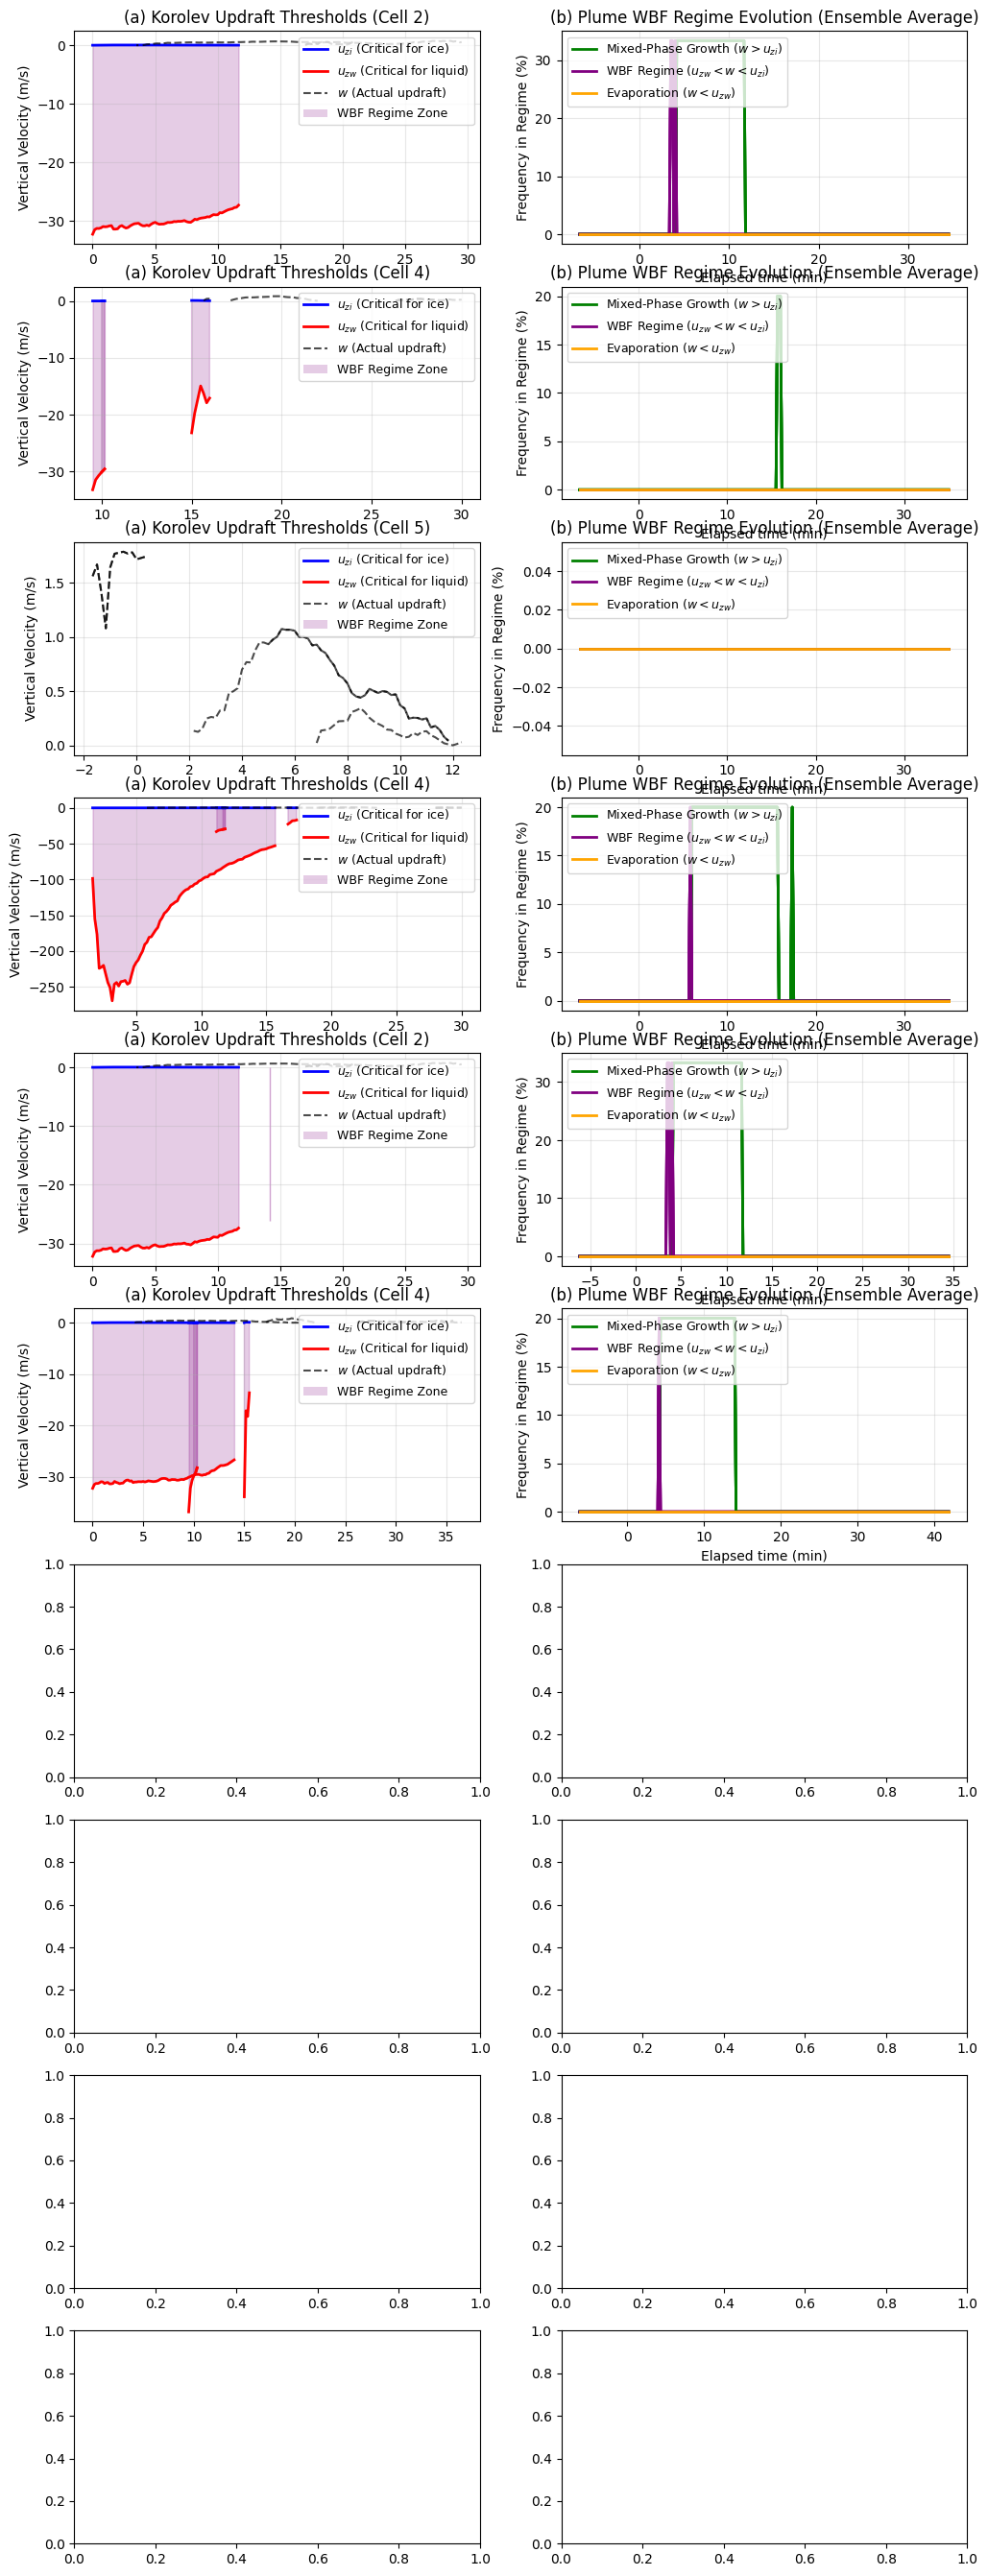

In [ ]:
icnt = 0
for i, (ds_key, ds_all) in enumerate(datasets.items()):
    if kind not in ds_all:
    
        icnt += 1
        continue    
# --- Figure: WBF Comparison ---
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
fig, axes = plt.subplots(nrows=len(datasets)-icnt, ncols=2, figsize=(12, (len(datasets)-icnt)*3.4))




for i, (ds_key, ds_all) in enumerate(datasets.items()):
    # if i>0:
    #     continue
    if kind not in ds_all:
        continue
    ds = ds_all[kind]#.sum('cell') if 'cell' in ds_all[kind].dims else ds_all[kind]

    
    print(f'processing {ds.sizes}')
    # Dataset units: t K, pp Pa, qv gm-3, rho kg/m³, wt m/s, qi gL-1, qc gm-3, icnc L-1, cdnc cm-3
    elapsed_s = (ds.time - SEEDING_START).values / np.timedelta64(1, 's')
    elapsed_min = elapsed_s / 60.0

    def extract_2d(var_name, ds):
        if var_name in ds.data_vars:
            if 'diameter' in ds[var_name].dims and 'cell' in ds[var_name].dims and 'time' in ds[var_name].dims:
                return ds[var_name].sum(dim='diameter').transpose('time', 'cell').values
            if 'cell' in ds[var_name].dims and 'time' in ds[var_name].dims:
                return ds[var_name].transpose('time', 'cell').values
            if 'time' in ds[var_name].dims:
                return ds[var_name].values
        return np.zeros((ds.sizes['time'], ds.sizes['cell']))

    rho = extract_2d('rho', ds)                 # kg/m³
    rho_safe = np.where(rho > 0, rho, np.nan)   # kg/m³
    temp = extract_2d('t', ds)                  # K
    pres_raw = extract_2d('pp', ds)             # hPa → Pa
    pres = pres_raw * 1e2                       # Pa
    qv_raw = extract_2d('qv', ds)               # qv: gm-3 → kg/kg = (g/m³)/1000/rho
    qv = (qv_raw / 1e3) / rho_safe              # kg/kg

    icnc = extract_2d('icnc', ds)               # L-1
    cdnc = extract_2d('cdnc', ds)               # cm-3
    Ni = icnc * 1e3                             # L-1 → m-3
    Nw = cdnc * 1e6                             # cm-3 → m-3
    qi_raw = extract_2d('qi', ds)               # gL-1 = kg/m³
    qc_raw = extract_2d('qc', ds)               # gm-3
    qi_kgkg = qi_raw / rho_safe                 # gL-1 → kg/kg
    qw_kgkg = (qc_raw / 1e3) / rho_safe         # gm-3 → kg/kg

    # wt: m3/s (vertical velocity), use directly
    wt = extract_2d('wt', ds)
    grid_density = ds['dz'].T * ds.attrs['delta_y'] * rho_safe
    w = wt / grid_density

    # Sanity: assumed units and value ranges for Korolev inputs
    def _stats(a):
        a = np.asarray(a)
        valid = np.isfinite(a) & (a != 0)
        if not np.any(valid):
            return np.nan, np.nan, np.nan
        a = a[valid]
        return np.nanmin(a), np.nanmedian(a), np.nanmax(a)

    checks = [
        ("temp", temp, "K"),
        ("rho", rho, "kg/m3"),
        ("pres", pres, "Pa"),
        ("qv", qv, "kg/kg"),
        ("Ni", Ni, "m-3"),
        ("qi_kgkg", qi_kgkg, "kg/kg"),
        ("Nw", Nw, "m-3"),
        ("qw_kgkg", qw_kgkg, "kg/kg"),
        ("w", w, "m/s"),
    ]
    print("Korolev input sanity (assumed units → min, median, max):")
    for name, arr, unit in checks:
        lo, md, hi = _stats(arr)
        print(f"  {name} [{unit}]: min={lo:.4g}  median={md:.4g}  max={hi:.4g}")

    wi, wc, ri, rw = korolev(temp, pres, rho, qv, Ni, qi_kgkg, Nw, qw_kgkg)

    # Optional: Korolev outputs
    print("\nKorolev outputs:")
    for name, arr in [("ri", ri), ("rw", rw), ("wi", wi), ("wc", wc)]:
        lo, md, hi = _stats(arr)
        print(f"  {name}: min={lo:.4g}  median={md:.4g}  max={hi:.4g}")

    # --- Classify Regimes (Korolev: wi=u_zi critical ice, wc=u_zw critical liquid) ---
    # WBF: u_zw < w < u_zi (ice grows, liquid evaporates). Growth: w >= u_zi. Evap: w <= u_zw.
    is_wbf = (w > wc) & (w < wi)
    is_growth = (w >= wi)
    is_evap = (w <= wc)

    # Calculate fraction of time in each regime (ensemble average across cells)
    frac_wbf = np.mean(is_wbf, axis=1) * 100
    frac_growth = np.mean(is_growth, axis=1) * 100
    frac_evap = np.mean(is_evap, axis=1) * 100
    print(frac_wbf.max(), frac_growth.max(), frac_evap.max())
    

    # Panel A: Critical velocities vs actual velocity (for a representative cell, e.g., cell 0)
    cell_idx = 0
    for cell_idx in range(ds.sizes['cell']):
        ax = axes[i, 0]
        ax.plot(elapsed_min, wi[:, cell_idx], 'b-', lw=2)
        ax.plot(elapsed_min, wc[:, cell_idx], 'r-', lw=2)
        ax.plot(elapsed_min, w[:, cell_idx], 'k--', lw=1.5, alpha=0.7)
        ax.fill_between(elapsed_min, wc[:, cell_idx], wi[:, cell_idx], color='purple', alpha=0.2)
        ax.set_ylabel('Vertical Velocity (m/s)')
        ax.set_title(f'(a) Korolev Updraft Thresholds (Cell {cell_idx})')
        ax.grid(True, alpha=0.3)

        # Panel B: Ensemble Regime Frequency
        ax = axes[i, 1]
        ax.plot(elapsed_min, frac_growth, 'g-', lw=2)
        ax.plot(elapsed_min, frac_wbf, 'purple', lw=2)
        ax.plot(elapsed_min, frac_evap, 'orange', lw=2)
        ax.set_xlabel('Elapsed time (min)')
        ax.set_ylabel('Frequency in Regime (%)')
        ax.set_title('(b) Plume WBF Regime Evolution (Ensemble Average)')
        ax.grid(True, alpha=0.3)
    # Legend entries (built separately from plot calls)
    handles_a = [
        Line2D([0], [0], color='b', ls='-', lw=2),
        Line2D([0], [0], color='r', ls='-', lw=2),
        Line2D([0], [0], color='k', ls='--', lw=1.5, alpha=0.7),
        Patch(facecolor='purple', alpha=0.2),
    ]
    labels_a = ['$u_{zi}$ (Critical for ice)', '$u_{zw}$ (Critical for liquid)', '$w$ (Actual updraft)', 'WBF Regime Zone']
    axes[i, 0].legend(handles=handles_a, labels=labels_a, loc='upper right', fontsize=9)
    handles_b = [
        Line2D([0], [0], color='g', ls='-', lw=2),
        Line2D([0], [0], color='purple', ls='-', lw=2),
        Line2D([0], [0], color='orange', ls='-', lw=2),
    ]
    labels_b = ['Mixed-Phase Growth ($w > u_{zi}$)', 'WBF Regime ($u_{zw} < w < u_{zi}$)', 'Evaporation ($w < u_{zw}$)']
    axes[i, 1].legend(handles=handles_b, labels=labels_b, loc='upper left', fontsize=9)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'figure_korolev_wbf_regime.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'figure_korolev_wbf_regime.png'}")


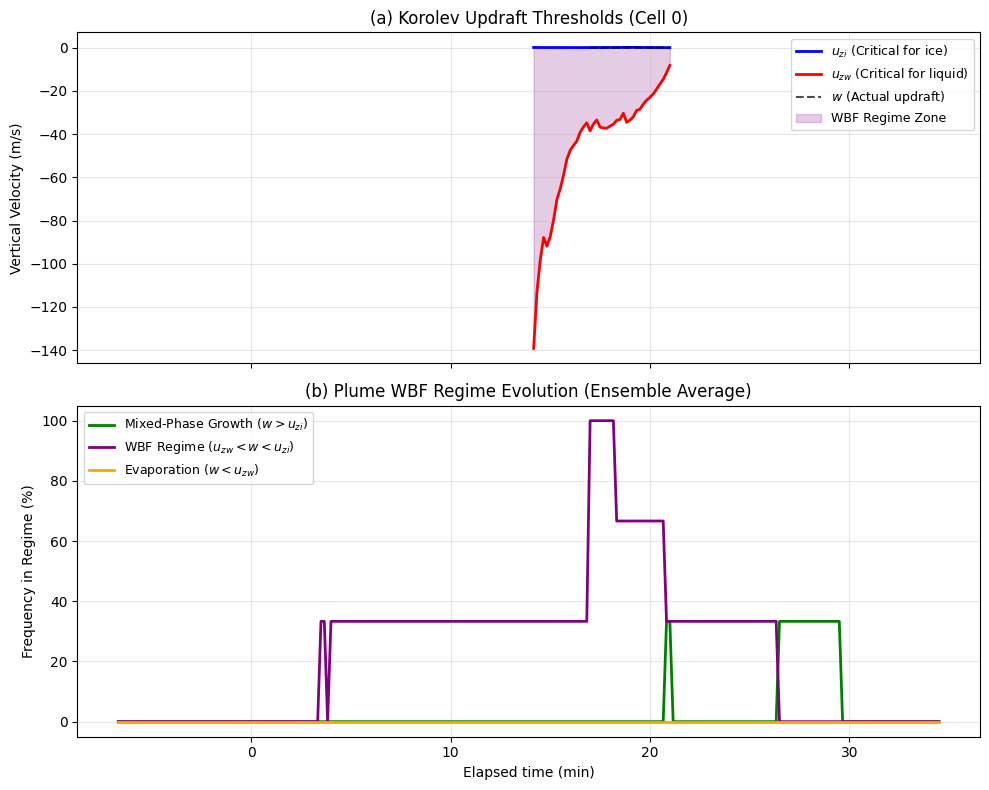

Saved: output/figure_korolev_wbf_regime.png


In [ ]:
# --- Figure: WBF Comparison ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Panel A: Critical velocities vs actual velocity (for a representative cell, e.g., cell 0)
cell_idx = 0
ax = axes[0]
ax.plot(elapsed_min, wi[:, cell_idx], 'b-', label='$u_{zi}$ (Critical for ice)', lw=2)
ax.plot(elapsed_min, wc[:, cell_idx], 'r-', label='$u_{zw}$ (Critical for liquid)', lw=2)
ax.plot(elapsed_min, w[:, cell_idx], 'k--', label='$w$ (Actual updraft)', lw=1.5, alpha=0.7)
ax.fill_between(elapsed_min, wc[:, cell_idx], wi[:, cell_idx], color='purple', alpha=0.2, label='WBF Regime Zone')

ax.set_ylabel('Vertical Velocity (m/s)')
ax.set_title(f'(a) Korolev Updraft Thresholds (Cell {cell_idx})')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
# ax.set_ylim(-1, 5) # Adjust limits as needed depending on wt units

# Panel B: Ensemble Regime Frequency
ax = axes[1]
ax.plot(elapsed_min, frac_growth, 'g-', label='Mixed-Phase Growth ($w > u_{zi}$)', lw=2)
ax.plot(elapsed_min, frac_wbf, 'purple', label='WBF Regime ($u_{zw} < w < u_{zi}$)', lw=2)
ax.plot(elapsed_min, frac_evap, 'orange', label='Evaporation ($w < u_{zw}$)', lw=2)

ax.set_xlabel('Elapsed time (min)')
ax.set_ylabel('Frequency in Regime (%)')
ax.set_title('(b) Plume WBF Regime Evolution (Ensemble Average)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
# ax.set_xlim(0, 30)
# ax.set_ylim(-5, 105)
# ax.set_yscale('log')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'figure_korolev_wbf_regime.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'figure_korolev_wbf_regime.png'}")
